In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tree = os.walk('data')

In [3]:
for item in tree:
    print(item)

('data', ['.ipynb_checkpoints', '2020-12-03', '2020-12-04', '2020-12-05', '2020-12-06', '2020-12-07', '2020-12-08', '2020-12-09'], [])
('data\\.ipynb_checkpoints', [], [])
('data\\2020-12-03', ['.ipynb_checkpoints', 'Alexey_Smirnov', 'Anton_Petrov', 'Kirill_Petrov', 'Petr_Fedorov', 'Vasiliy_Ivanov', 'Vasiliy_Petrov'], [])
('data\\2020-12-03\\.ipynb_checkpoints', [], [])
('data\\2020-12-03\\Alexey_Smirnov', [], ['data.csv'])
('data\\2020-12-03\\Anton_Petrov', [], ['data.csv'])
('data\\2020-12-03\\Kirill_Petrov', [], ['data.csv'])
('data\\2020-12-03\\Petr_Fedorov', [], ['data.csv'])
('data\\2020-12-03\\Vasiliy_Ivanov', [], ['data.csv'])
('data\\2020-12-03\\Vasiliy_Petrov', [], ['data.csv'])
('data\\2020-12-04', ['.ipynb_checkpoints', 'Alexey_Smirnov', 'Kirill_Fedorov', 'Petr_Fedorov', 'Petr_Ivanov', 'Petr_Smirnov', 'Rostislav_Fedorov', 'Rostislav_Ivanov', 'Rostislav_Smirnov', 'Vasiliy_Ivanov'], [])
('data\\2020-12-04\\.ipynb_checkpoints', [], [])
('data\\2020-12-04\\Alexey_Smirnov', [], 

In [4]:
tree = os.walk('data')
data_files = []
target_file = 'data.csv'
for item in tree:
    files = item[-1]
    if len(files) > 0 and target_file in files:
        path = os.path.join(item[0], target_file)
        data_files.append(path)

In [5]:
data_files

['data\\2020-12-03\\Alexey_Smirnov\\data.csv',
 'data\\2020-12-03\\Anton_Petrov\\data.csv',
 'data\\2020-12-03\\Kirill_Petrov\\data.csv',
 'data\\2020-12-03\\Petr_Fedorov\\data.csv',
 'data\\2020-12-03\\Vasiliy_Ivanov\\data.csv',
 'data\\2020-12-03\\Vasiliy_Petrov\\data.csv',
 'data\\2020-12-04\\Alexey_Smirnov\\data.csv',
 'data\\2020-12-04\\Kirill_Fedorov\\data.csv',
 'data\\2020-12-04\\Petr_Fedorov\\data.csv',
 'data\\2020-12-04\\Petr_Ivanov\\data.csv',
 'data\\2020-12-04\\Petr_Smirnov\\data.csv',
 'data\\2020-12-04\\Rostislav_Fedorov\\data.csv',
 'data\\2020-12-04\\Rostislav_Ivanov\\data.csv',
 'data\\2020-12-04\\Rostislav_Smirnov\\data.csv',
 'data\\2020-12-04\\Vasiliy_Ivanov\\data.csv',
 'data\\2020-12-05\\Alexey_Fedorov\\data.csv',
 'data\\2020-12-05\\Alexey_Petrov\\data.csv',
 'data\\2020-12-05\\Kirill_Smirnov\\data.csv',
 'data\\2020-12-05\\Petr_Ivanov\\data.csv',
 'data\\2020-12-05\\Petr_Smirnov\\data.csv',
 'data\\2020-12-05\\Rostislav_Smirnov\\data.csv',
 'data\\2020-12-06\\

In [6]:
data_files_df = []
for path in data_files:
    df = pd.read_csv(path, index_col = 0)
    date, name = path.split('\\')[1:3]
    df['name'] = name
    df['date'] = date
    data_files_df.append(df)

In [7]:
data_files_df

[   product_id  quantity            name        date
 0          47         1  Alexey_Smirnov  2020-12-03
 1          57         1  Alexey_Smirnov  2020-12-03
 2          14         2  Alexey_Smirnov  2020-12-03
 3          52         1  Alexey_Smirnov  2020-12-03
 4           1         4  Alexey_Smirnov  2020-12-03
 5          94         4  Alexey_Smirnov  2020-12-03,
    product_id  quantity          name        date
 0          56         5  Anton_Petrov  2020-12-03
 1          27         3  Anton_Petrov  2020-12-03
 2          82         1  Anton_Petrov  2020-12-03
 3          61         1  Anton_Petrov  2020-12-03
 4          88         5  Anton_Petrov  2020-12-03,
    product_id  quantity           name        date
 0          77         1  Kirill_Petrov  2020-12-03
 1          10         3  Kirill_Petrov  2020-12-03
 2          83         2  Kirill_Petrov  2020-12-03
 3          78         3  Kirill_Petrov  2020-12-03,
    product_id  quantity          name        date
 0       

In [8]:
df = pd.concat(data_files_df, ignore_index = True)

In [9]:
df

,product_id,quantity,name,date
0,47,1,Alexey_Smirnov,2020-12-03
1,57,1,Alexey_Smirnov,2020-12-03
2,14,2,Alexey_Smirnov,2020-12-03
3,52,1,Alexey_Smirnov,2020-12-03
4,1,4,Alexey_Smirnov,2020-12-03
...,...,...,...,...
156,66,4,Rostislav_Petrov,2020-12-09
157,39,2,Rostislav_Petrov,2020-12-09
158,82,4,Vasiliy_Ivanov,2020-12-09
159,74,2,Vasiliy_Ivanov,2020-12-09


In [10]:
df.groupby('name', as_index = False).\
    agg({'quantity': 'sum'}). \
    sort_values('quantity', ascending = False)

,name,quantity
3,Alexey_Smirnov,52
13,Petr_Smirnov,52
6,Anton_Smirnov,45
10,Petr_Fedorov,34
7,Kirill_Fedorov,28
16,Rostislav_Petrov,28
19,Vasiliy_Ivanov,27
0,Alexey_Fedorov,24
4,Anton_Ivanov,23
11,Petr_Ivanov,21


In [11]:
top_10 = df.groupby('product_id', as_index = False). \
    agg({'quantity': 'sum'}). \
    sort_values('quantity', ascending = False). \
    head(10)

In [12]:
top_10

,product_id,quantity
22,27,20
42,56,18
51,74,15
21,24,15
32,41,14
46,66,13
66,94,13
27,34,13
38,50,12
65,92,12


<Axes: xlabel='product_id', ylabel='quantity'>

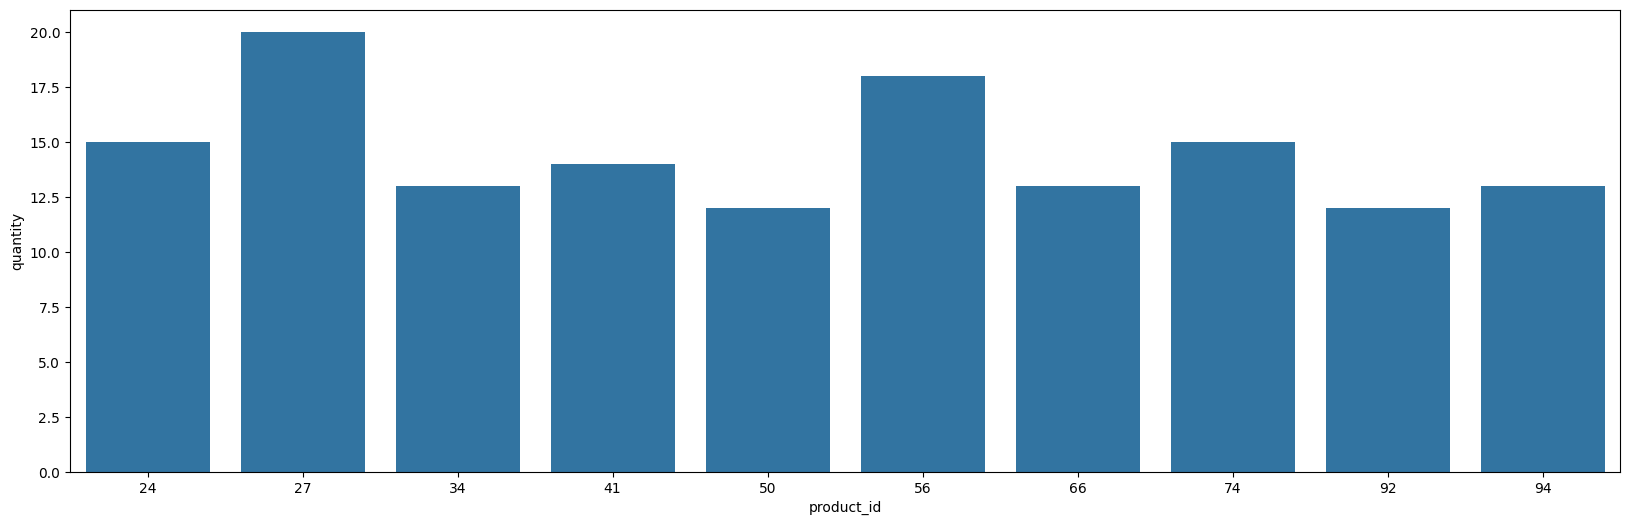

In [13]:
plt.figure(figsize=(20,6))
sns.barplot(data = top_10, x = 'product_id', y = 'quantity')

In [14]:
sales_by_date = df.groupby('date', as_index = False). \
    agg({'quantity': 'sum'})

<Axes: xlabel='date', ylabel='quantity'>

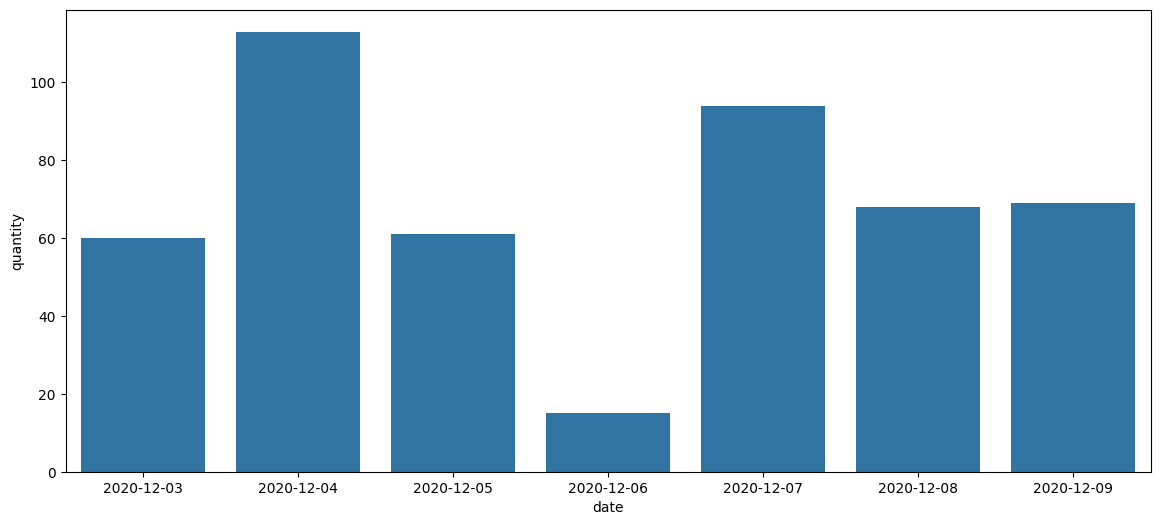

In [17]:
plt.figure(figsize = (14,6))
sns.barplot(data = sales_by_date, x = 'date', y = 'quantity')